In [46]:
# Load the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# Load and Inspect dataset
df =pd.read_csv('personal_finance.csv')


In [48]:
# Information about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    75000 non-null  str    
 1   user_id           75000 non-null  str    
 2   transaction_date  75000 non-null  str    
 3   month             75000 non-null  str    
 4   year              75000 non-null  int64  
 5   transaction_type  75000 non-null  str    
 6   category          75000 non-null  str    
 7   amount_ngn        75000 non-null  float64
 8   description       75000 non-null  str    
 9   payment_method    75000 non-null  str    
 10  bank              75000 non-null  str    
 11  savings_goal_met  50006 non-null  str    
 12  budget_category   75000 non-null  str    
 13  notes             53382 non-null  str    
dtypes: float64(1), int64(1), str(12)
memory usage: 8.0 MB


In [50]:
 df.head(100)

,transaction_id,user_id,transaction_date,month,year,transaction_type,category,amount_ngn,description,payment_method,bank,savings_goal_met,budget_category,notes
0,TXN-500000,USR-500752,2022-11-29,November,2022,Expense,Investment,68080.0,Reflect despite loss.,Card,Palmpay,No,Investment,Planned
1,TXN-500001,USR-502966,2021-02-14,February,2021,Expense,Investment,15290.0,Model sea everybody American same.,USSD,Opay,Yes,Investment,NaN
2,TXN-500002,USR-502387,2021-08-16,August,2021,Expense,Transport,22650.0,Thank assume claim.,Cash,Access,No,Transport,Unexpected
3,TXN-500003,USR-502251,2022-07-05,July,2022,Expense,Entertainment,32220.0,Possible color account spend.,POS,Kuda,No,Entertainment,Monthly
4,TXN-500004,USR-502756,2023-08-24,August,2023,Expense,Investment,15710.0,Same democratic.,Card,Access,NaN,Investment,Planned
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,TXN-500095,USR-503170,2021-09-09,September,2021,Expense,Investment,5270.0,Level garden go conference.,POS,UBA,Yes,Investment,Annual
96,TXN-500096,USR-503360,2023-11-13,November,2023,Expense,Utilities,33490.0,Poor exactly explain.,Cash,First Bank,NaN,Utilities,NaN
97,TXN-500097,USR-500066,2023-03-31,March,2023,Expense,Transport,43600.0,Simple specific peace.,Cash,First Bank,NaN,Transport,Urgent
98,TXN-500098,USR-503768,2021-01-09,January,2021,Expense,Airtime/Data,132360.0,Serve cause beat put international.,Bank Transfer,GTBank,No,Airtime/Data,NaN


In [15]:
df.describe

<bound method NDFrame.describe of       transaction_id     user_id transaction_date     month  year  \
0         TXN-500000  USR-500752       2022-11-29  November  2022   
1         TXN-500001  USR-502966       2021-02-14  February  2021   
2         TXN-500002  USR-502387       2021-08-16    August  2021   
3         TXN-500003  USR-502251       2022-07-05      July  2022   
4         TXN-500004  USR-502756       2023-08-24    August  2023   
...              ...         ...              ...       ...   ...   
74995     TXN-574995  USR-501950       2022-06-12      June  2022   
74996     TXN-574996  USR-503014       2022-11-13  November  2022   
74997     TXN-574997  USR-500892       2021-08-03    August  2021   
74998     TXN-574998  USR-502350       2021-02-05  February  2021   
74999     TXN-574999  USR-500733       2022-06-08      June  2022   

      transaction_type       category  amount_ngn  \
0              Expense     Investment     68080.0   
1              Expense     Inve

In [51]:
# Check for negative amounts
df[df['amount_ngn']<0]

,transaction_id,user_id,transaction_date,month,year,transaction_type,category,amount_ngn,description,payment_method,bank,savings_goal_met,budget_category,notes


In [52]:
# Remove duplicates
dups = df[df.duplicated(subset=['transaction_id'], keep=False)]

In [31]:
import pandas as pd

def get_anomalies(df):
    # 1. Negative amounts
    neg = df[df['amount_ngn'] < 0]
    
    # 2. Duplicate transactions (using the corrected syntax from earlier)
    dups = df[df.duplicated(subset=['transaction_id'], keep=False)]
    
    # 3. Statistical outliers (IQR Method)
    Q1 = df['amount_ngn'].quantile(0.25)
    Q3 = df['amount_ngn'].quantile(0.75)
    IQR = Q3 - Q1  # Fixed variable name
    
    # Combined with '|' (OR) and fixed parentheses
    outliers = df[(df['amount_ngn'] < (Q1 - 1.5 * IQR)) | (df['amount_ngn'] > (Q3 + 1.5 * IQR))]
    
    return neg, dups, outliers

# Unpacking and printing the results
neg_anomalies, duplicate_anomalies, statistical_anomalies = get_anomalies(df)

print(f"Negative: {len(neg_anomalies)}, Duplicates: {len(duplicate_anomalies)}, Outliers: {len(statistical_anomalies)}")

Negative: 0, Duplicates: 0, Outliers: 5741


In [53]:
import pandas as pd

def get_monthly_anomalies(df):
    monthly_anomalies = []
    
    # Iterate through each unique month
    for month in df['month'].unique():
        month_data = df[df['month'] == month]
        
        # Calculate IQR bounds for the current month
        Q1 = month_data['amount_ngn'].quantile(0.25)
        Q3 = month_data['amount_ngn'].quantile(0.75)
        IQR = Q3 - Q1
        
        outliers = month_data[(month_data['amount_ngn'] < (Q1 - 1.5 * IQR)) | 
                              (month_data['amount_ngn'] > (Q3 + 1.5 * IQR))]
        
        if not outliers.empty:
            monthly_anomalies.append(outliers)
            
    # CRITICAL FIX: Handle the case where no anomalies are found across any month
    if not monthly_anomalies:
        return pd.DataFrame(columns=df.columns)
        
    return pd.concat(monthly_anomalies)

# Running the function
monthly_outliers = get_monthly_anomalies(df)
print(f"Found {len(monthly_outliers)} anomalies when analyzed by month.")

Found 5782 anomalies when analyzed by month.


In [34]:
# 2. Separate income and expense records; compute net savings per user per month
monthly_summary = df.pivot_table(index=['user_id', 'year', 'month'], 
                                 columns='transaction_type', 
                                 values='amount_ngn', 
                                 aggfunc='sum', 
                                 fill_value=0)

# Ensure columns exist
if 'Income' not in monthly_summary.columns: monthly_summary['Income'] = 0
if 'Expense' not in monthly_summary.columns: monthly_summary['Expense'] = 0

monthly_summary['Net_Savings'] = monthly_summary['Income'] - monthly_summary['Expense']


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    75000 non-null  str    
 1   user_id           75000 non-null  str    
 2   transaction_date  75000 non-null  str    
 3   month             75000 non-null  str    
 4   year              75000 non-null  int64  
 5   transaction_type  75000 non-null  str    
 6   category          75000 non-null  str    
 7   amount_ngn        75000 non-null  float64
 8   description       75000 non-null  str    
 9   payment_method    75000 non-null  str    
 10  bank              75000 non-null  str    
 11  savings_goal_met  50006 non-null  str    
 12  budget_category   75000 non-null  str    
 13  notes             53382 non-null  str    
dtypes: float64(1), int64(1), str(12)
memory usage: 8.0 MB


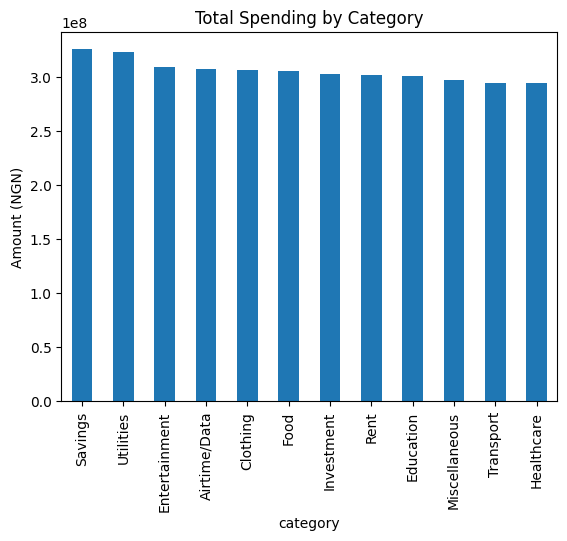

In [54]:
# 3. Bar chart: Total spending by category
spending_by_category = df[df['transaction_type'] == 'Expense'].groupby('category')['amount_ngn'].sum().sort_values(ascending=False)
spending_by_category.plot(kind='bar', title='Total Spending by Category')
plt.ylabel('Amount (NGN)')
plt.show()


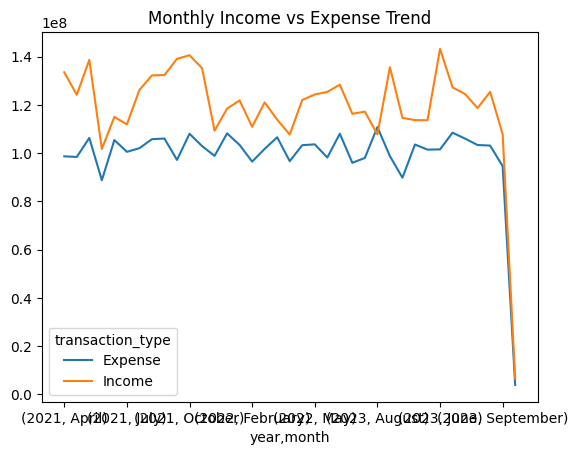

In [37]:
# 4. Line chart: Monthly income vs expense trend
monthly_trend = df.groupby(['year', 'month', 'transaction_type'])['amount_ngn'].sum().unstack(fill_value=0)
monthly_trend.plot(kind='line', title='Monthly Income vs Expense Trend')
plt.show()


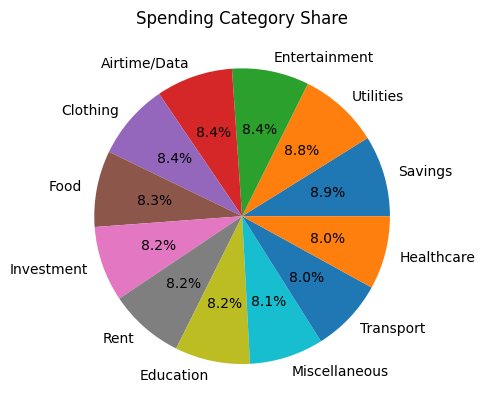

In [55]:
# 5. Pie chart: Spending category share
spending_by_category.plot(kind='pie', autopct='%1.1f%%', title='Spending Category Share')
plt.show()


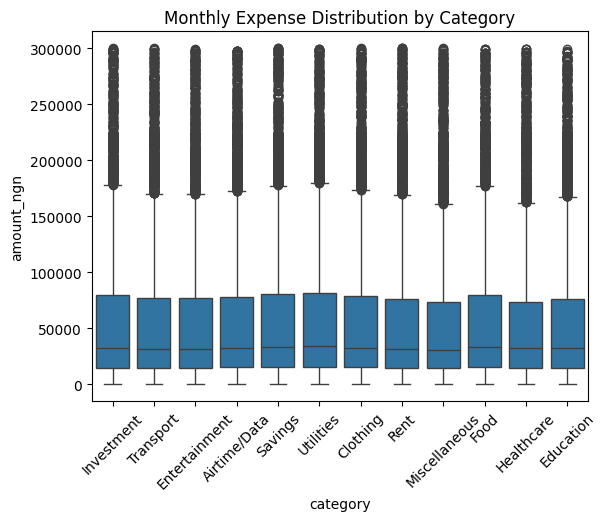

In [56]:
# 6. Box plot: Monthly expense distribution by category
expense_df = df[df['transaction_type'] == 'Expense']
sns.boxplot(x='category', y='amount_ngn', data=expense_df)
plt.title('Monthly Expense Distribution by Category')
plt.xticks(rotation=45)
plt.show()


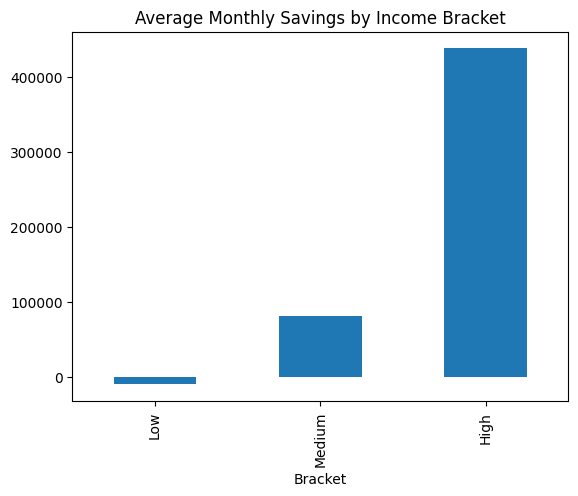

In [57]:
# 7. Bar chart: Average monthly savings by user income bracket
avg_income_per_user = monthly_summary.groupby('user_id')['Income'].mean()

def get_bracket(income):
    if income < 100000: return 'Low'
    elif income < 500000: return 'Medium'
    else: return 'High'

avg_income_per_user_df = avg_income_per_user.to_frame('Avg_Income')
avg_income_per_user_df['Bracket'] = avg_income_per_user_df['Avg_Income'].apply(get_bracket)
avg_savings_per_user = monthly_summary.groupby('user_id')['Net_Savings'].mean()
user_stats = avg_income_per_user_df.join(avg_savings_per_user)
bracket_savings = user_stats.groupby('Bracket')['Net_Savings'].mean().sort_values()
bracket_savings.plot(kind='bar', title='Average Monthly Savings by Income Bracket')
plt.show()


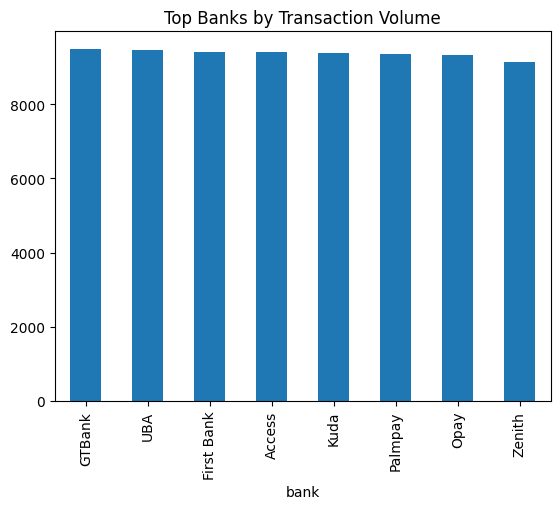

In [41]:
# 8. Bar chart: Top banks by transaction volume
df['bank'].value_counts().plot(kind='bar', title='Top Banks by Transaction Volume')
plt.show()


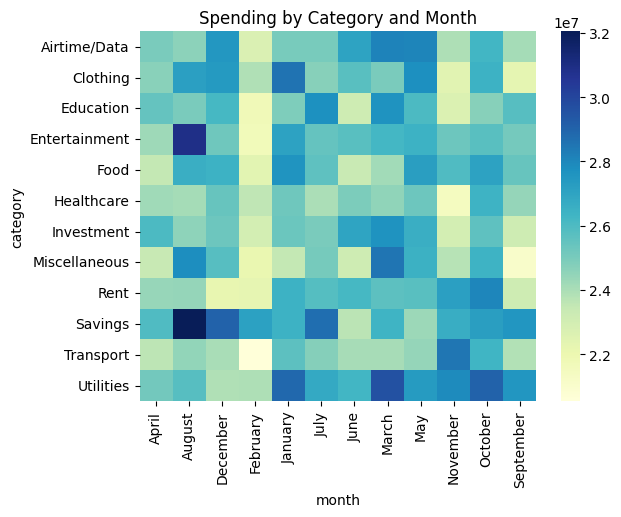

In [58]:
# 9. Heatmap: Spending by category and month
expense_heatmap = df[df['transaction_type'] == 'Expense'].pivot_table(index='category', columns='month', values='amount_ngn', aggfunc='sum')
sns.heatmap(expense_heatmap, annot=False, cmap='YlGnBu')
plt.title('Spending by Category and Month')
plt.show()


In [59]:
# 10. Flag over-spenders
monthly_summary['Overspent'] = monthly_summary['Expense'] > monthly_summary['Income']
overspenders = monthly_summary.groupby('user_id')['Overspent'].sum()
flagged_users = overspenders[overspenders > 3].index.tolist()
print(f"Flagged {len(flagged_users)} users.")


Flagged 4983 users.


In [44]:
# 11. Summary insights are derived from the aggregate calculations above
# e.g., analyzing flagged_users, bracket_savings, and spending_by_category.


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    75000 non-null  str    
 1   user_id           75000 non-null  str    
 2   transaction_date  75000 non-null  str    
 3   month             75000 non-null  str    
 4   year              75000 non-null  int64  
 5   transaction_type  75000 non-null  str    
 6   category          75000 non-null  str    
 7   amount_ngn        75000 non-null  float64
 8   description       75000 non-null  str    
 9   payment_method    75000 non-null  str    
 10  bank              75000 non-null  str    
 11  savings_goal_met  50006 non-null  str    
 12  budget_category   75000 non-null  str    
 13  notes             53382 non-null  str    
dtypes: float64(1), int64(1), str(12)
memory usage: 8.0 MB


In [61]:
#overview of column
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    75000 non-null  str    
 1   user_id           75000 non-null  str    
 2   transaction_date  75000 non-null  str    
 3   month             75000 non-null  str    
 4   year              75000 non-null  int64  
 5   transaction_type  75000 non-null  str    
 6   category          75000 non-null  str    
 7   amount_ngn        75000 non-null  float64
 8   description       75000 non-null  str    
 9   payment_method    75000 non-null  str    
 10  bank              75000 non-null  str    
 11  savings_goal_met  50006 non-null  str    
 12  budget_category   75000 non-null  str    
 13  notes             53382 non-null  str    
dtypes: float64(1), int64(1), str(12)
memory usage: 8.0 MB
None


In [63]:
#save the file
df = df.to_csv('processed_finance_data.csv',index =false)

NameError: name 'false' is not defined